In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

import matplotlib.pyplot as plt

In [2]:
import sys
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow version: 2.19.0
Keras version: 3.10.0


In [3]:
# Cargar MNIST usando el 'keras' ya importado en el notebook
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Imprimir tamaño (shape) y número de ejemplos de cada conjunto
print("x_train shape:", x_train.shape, "| num samples:", len(x_train))
print("y_train shape:", y_train.shape, "| num samples:", len(y_train))
print("x_test  shape:", x_test.shape,  "| num samples:", len(x_test))
print("y_test  shape:", y_test.shape,  "| num samples:", len(y_test))

x_train shape: (60000, 28, 28) | num samples: 60000
y_train shape: (60000,) | num samples: 60000
x_test  shape: (10000, 28, 28) | num samples: 10000
y_test  shape: (10000,) | num samples: 10000


In [4]:
#Qué tipo de dato es x_train
print("Tipo de dato de x_train:", type(x_train))

Tipo de dato de x_train: <class 'numpy.ndarray'>


In [5]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

Text(0.5, 1.0, 'Etiqueta: 5')

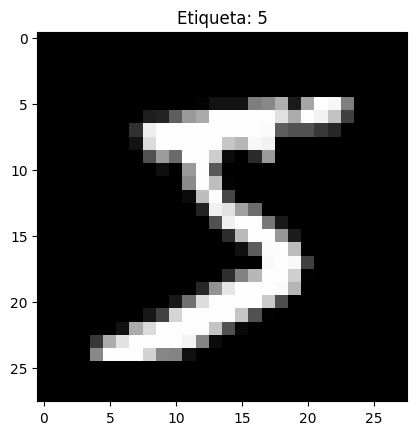

In [6]:
#Imprima la imágen del arreglo x_train[0]
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Etiqueta: {y_train[0]}")

Text(0.5, 1.0, 'Etiqueta: 4')

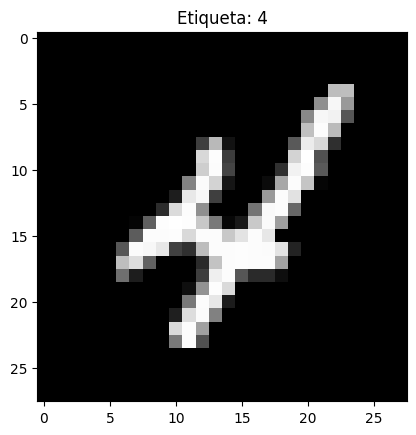

In [7]:
#Imprima la imágen del arreglo x_train[9]
plt.imshow(x_train[9], cmap='gray')
plt.title(f"Etiqueta: {y_train[9]}")

In [8]:
print(y_train[9])

4


In [9]:
# Normaliza las imágenes (x_train y x_test) dividiendo por 255.0.
# Nota: las etiquetas (y_train) no deben normalizarse para clasificación.
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

In [10]:
print(x_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [11]:
!nvidia-smi

Fri Feb 27 20:18:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
#Agregue la variable perdida, que es igual a la función de pérdida de entropía cruzada categórica (categorical crossentropy) con 'from_logits=True'.
perdida = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [13]:
#El optimizador a usar, use la variable optimizador con Adam con un learning rate de 0.03
optimizador = keras.optimizers.Adam(learning_rate=0.03)

In [14]:
#Cree una variable métrica, donde el validador sea el accuracy
metrica = keras.metrics.SparseCategoricalAccuracy()

In [15]:
#Grafo de red neuronal
miModelo = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(10, activation='linear')
])

In [16]:
#Compilemos el modelo con el optimizador, la función de pérdida y la métrica que hemos creado
miModelo.compile(optimizer=optimizador, loss=perdida, metrics=[metrica])

In [17]:
#Entrena el modelo con los datos de entrenamiento (x_train, y_train) durante 10 a 15 épocas
miModelo.fit(x_train, y_train, epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.5360 - sparse_categorical_accuracy: 0.8427
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3450 - sparse_categorical_accuracy: 0.9123
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3268 - sparse_categorical_accuracy: 0.9215
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3254 - sparse_categorical_accuracy: 0.9226
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.3292 - sparse_categorical_accuracy: 0.9236
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3225 - sparse_categorical_accuracy: 0.9236
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.3084 - sparse_categorical_accuracy: 0.9268
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2986 - sparse_categorical_accuracy: 0.9307
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3042 - sparse_categorical_accuracy: 0.9268
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━

In [18]:
#Evaluar en el conjunto de prueba
test_loss, test_acc = miModelo.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}\nTest loss: {test_loss:.4f}")

313/313 - 2s - 5ms/step - loss: 0.3976 - sparse_categorical_accuracy: 0.9169
Test accuracy: 0.9169
Test loss: 0.3976


In [19]:
miModelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,456 (302.57 KB)

 Trainable params: 25,818 (100.85 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 51,638 (201.71 KB)

In [21]:
#Dale persistencia al modelo con extensión .keras
miModelo.save("/content/modelo_numeros.keras")

In [ ]:
#Importa la librería de Google Drive para montar tu unidad de Google Drive

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
Vector de resultados: [ 47.66291   -21.429323   17.053516   22.706322  -28.702972   19.77187
  28.570356   12.186643   13.85372     4.4418344]


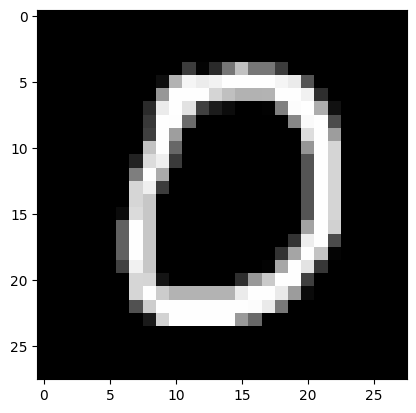

In [22]:
#Guardar en la variable predicción, la imagen que está en x_test[10]. Muestrame la imagen, prediga la etiqueta mostrando el vector de resultados, no aplique softmath
prediccion = x_test[10]
plt.imshow(prediccion, cmap='gray')
#Predecir la etiqueta de la imagen
predicciones = miModelo.predict(prediccion.reshape(1, 28, 28))
print("Vector de resultados:", predicciones[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Número: 3
Etiqueta predicha: 3
Probabilidad: 99.77%


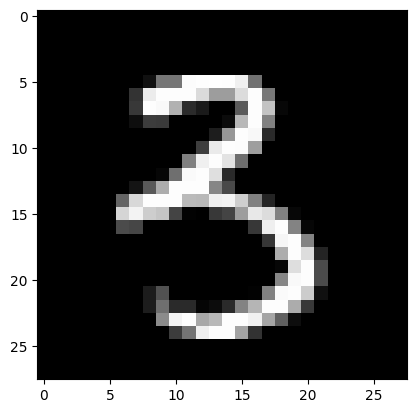

In [23]:
#Convierta el logits a probabilidades en la predicción usando softmax. Haga la prediccion del numero que está en la posicion 5000, muestre el número, la etiqueta que predice y la probabilidad de tener ese numero en porcentaje
prediccion = x_test[5000]
plt.imshow(prediccion, cmap='gray')
#Predecir la etiqueta de la imagen
predicciones = miModelo.predict(prediccion.reshape(1, 28, 28))
probabilidades = tf.nn.softmax(predicciones[0])
etiqueta_predicha = tf.argmax(probabilidades).numpy()
probabilidad = probabilidades[etiqueta_predicha].numpy() * 100
print(f"Número: {y_test[5000]}")
print(f"Etiqueta predicha: {etiqueta_predicha}")
print(f"Probabilidad: {probabilidad:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


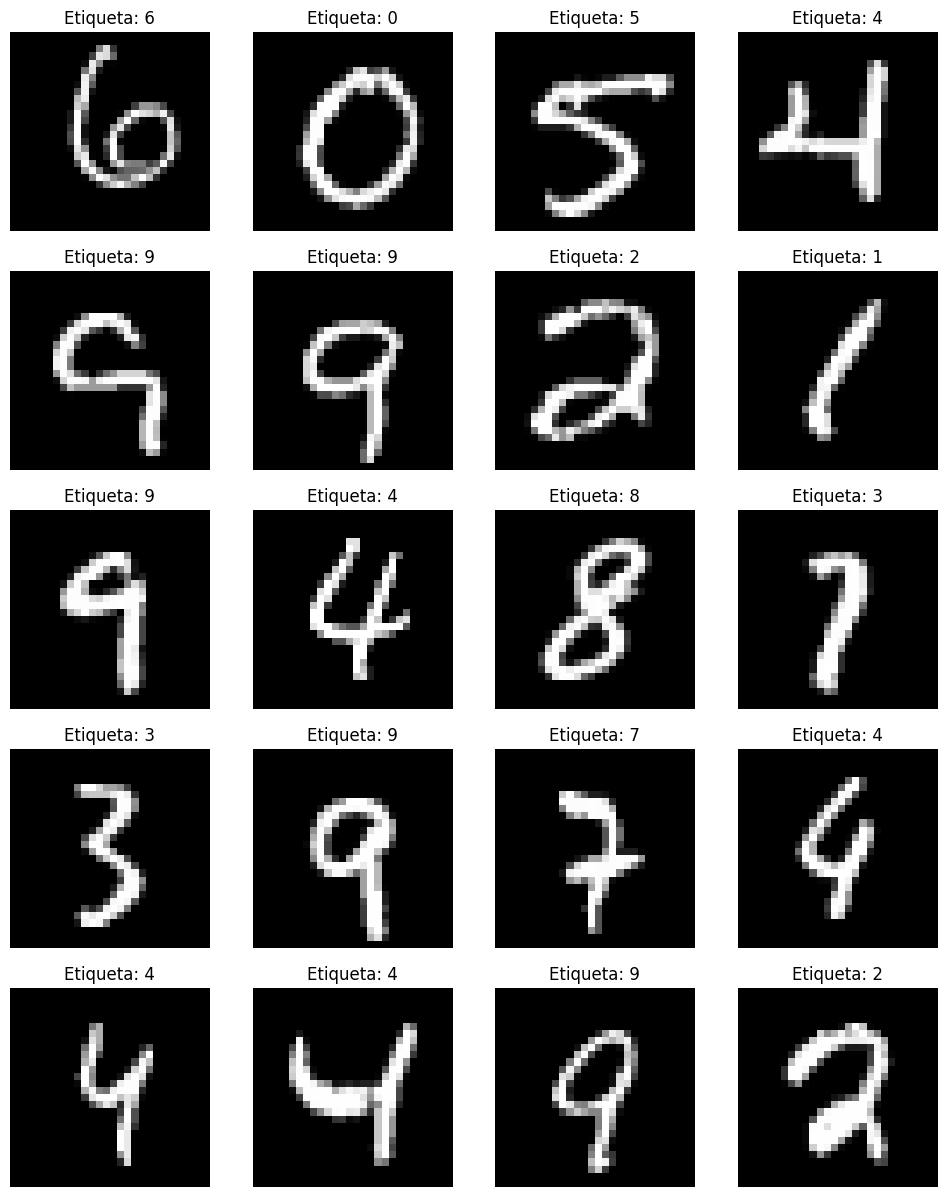

In [24]:
#Imprima las imagenes de la posicion 100 a la 120 de x_test, haga la prediccion, coloca la etiqueta en la parte superior y en la parte inferior la probabilidad de esa etiqueta, organiza los numeros en 4 columnas y 5 filas ajustando los tamaños
fig, axes = plt.subplots(5, 4, figsize=(12, 15))
for i, ax in enumerate(axes.flat):
    index = 100 + i
    imagen = x_test[index]
    ax.imshow(imagen, cmap='gray')
    predicciones = miModelo.predict(imagen.reshape(1, 28, 28))
    probabilidades = tf.nn.softmax(predicciones[0])
    etiqueta_predicha = tf.argmax(probabilidades).numpy()
    probabilidad = probabilidades[etiqueta_predicha].numpy() * 100
    ax.set_title(f"Etiqueta: {etiqueta_predicha}")
    ax.set_xlabel(f"Probabilidad: {probabilidad:.2f}%")
    ax.axis('off')

In [31]:
#Monte el Google Drive de la carpeta 'Mi unidad/numeros' en este cuaderno
from google.colab import drive
drive.mount('/content/drive/My Drive/numeros')

ValueError: Mountpoint must not contain a space.

In [30]:
!ls -la /drive/numeros/

ls: cannot access '/drive/numeros/': No such file or directory


In [29]:
from PIL import Image
import os

# nombres de los archivos que están en la carpeta "numeros"
archivos = ['0.jpg', '3.jpg', '5.jpg']
carpeta = 'numeros'

# cargar cada imagen, convertir a escala de grises, redimensionar a 28x28,
# normalizar y apilar en un arreglo de forma (N,28,28)
imagenes = []
for nombre in archivos:
    ruta = os.path.join(carpeta, nombre)
    img = Image.open(ruta).convert('L')          # imagen en gris
    img = img.resize((28, 28))                    # asegurar tamaño 28×28
    arr = np.array(img, dtype='float32') / 255.0  # normalizar [0,1]
    if arr.shape != (28, 28):
        arr = arr.reshape((28, 28))
    imagenes.append(arr)
imagenes = np.stack(imagenes)  # matriz de forma (3, 28, 28)

# predicciones con el modelo ya entrenado
logits = miModelo.predict(imagenes)          # (3, 10)
probs = tf.nn.softmax(logits, axis=1).numpy()  # convertir a numpy
etiquetas = np.argmax(probs, axis=1)
confianzas = np.max(probs, axis=1) * 100      # porcentaje

# mostrar cada imagen con su etiqueta y probabilidad
fig, axes = plt.subplots(1, len(imagenes), figsize=(12, 4))
if len(imagenes) == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.imshow(imagenes[i], cmap='gray')
    ax.set_title(f"Pred: {etiquetas[i]}\n{confianzas[i]:.2f}%")
    ax.axis('off')

FileNotFoundError: [Errno 2] No such file or directory: 'numeros/0.jpg'